# New amplifier: gain vs. frequency at multiple drive powers

Extends `new_amplifier_gain.ipynb`'s frequency sweep (which only ever sampled
TWO fixed drive powers, -40 dBm and 0 dBm) to a whole LIST of drive powers --
`0, -5, -10, -15, -20, -25` dBm by default -- sweeping the HP8673H 2-3 GHz at
EACH power level and overlaying `gain_db(f)` curves to see how gain vs.
frequency shape changes (compression, flatness) as drive power increases.

Reuses `HP8673H.frequency_sweep()` directly (same helper `new_amplifier_gain.
ipynb` uses) rather than reimplementing the sweep loop -- it already builds in
the settling-time protections documented in its own docstring: a larger one-
time `initial_settle_s` (default 1.0 s) after the first frequency/power jump
(AUTO PEAK re-levels on any >50 MHz change, which the very first jump almost
always is), and a smaller but still nonzero `settle_s` (default 0.05 s, NEVER
0) between each step -- `settle_s=0` is a confirmed real bug on this generator:
the analyzer's `INIT:IMM` fires before the generator has actually finished
processing the previous SCPI command, producing a false >13 dB "dip" at
specific frequencies that looks exactly like a real feature (see `hp8673h.py`'s
docstring and `notes.md`). Calling `frequency_sweep()` FRESH for each power
level (rather than only changing power once at the top) also means every power
level gets its own full `preset()` + `initial_settle_s`, so the generator's
leveling loop gets the same generous settle time after EVERY power change, not
just the very first one.

**Physical setup**: same coupled path as `new_amplifier_gain.ipynb`'s
"Compression point" section -- amplifier output -> isolator -> coupler ->
terminated load, coupler's **forward** sample port -> E4403B input -- used for
the WHOLE power list here (not just 0 dBm), since `POWER_LIST_DBM`'s highest
value (0 dBm) plus this amplifier's gain (~30 dB, from the prior sweep) is well
above what's safe to feed the E4403B directly. `COUPLING_DB` is the same 20 dB
datasheet value used there -- confirm it's still the same physical coupler
before trusting `estimated_output_dbm`/`estimated_gain_db`.

**RF switch**: the ZYSWA-2-50DR+ RF switch sits inline before the amplifier (generator -> switch RF IN, RF2 -> amplifier, RF1 -> dummy load -- see `notes.md`'s "Mini-Circuits ZYSWA-2-50DR+" section and `tests/rf_switch_test.ipynb`). It's absorptive, not reflective, and control HIGH is what routes RF IN to RF2 (the amplifier path); control LOW dumps everything into the RF1 dummy load instead. This sweep needs continuous CW through the amplifier, not the gated pulse pattern `rf_switch_test.ipynb`/`pulsed_odmr.py` use -- so AWG CH2 (the switch's control input) is set to a constant 5V DC level for the whole notebook, not a square wave, to hold the switch HIGH throughout every sweep.

In [33]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt

# driver modules live one level up, in experiment/ itself
sys.path.insert(0, "C:/Users/codin/Documents/projects/diamonds/experiment")

import ks33600a
from hp8673h import HP8673H
from e4403b import E4403B

AWG_RESOURCE = "USB0::0x0957::0x5707::MY53800810::INSTR"

# See notes.md -- GPIB bus numbering isn't stable, confirm with
# pyvisa.ResourceManager().list_resources() if these don't match.
gen = HP8673H("GPIB1::19::INSTR")
sa = E4403B("GPIB0::18::INSTR")
awg = ks33600a.KS33600A(AWG_RESOURCE)

# frequency_sweep() never touches RBW/VBW -- it inherits whatever the
# analyzer was last left at. Found manually fixed at 10 kHz here (left
# over from some earlier fine measurement), which with SWE:TIME:AUTO ON
# forces a ~12.9s sweep time across this notebook's 1 GHz span (vs. ~4ms
# once RBW is auto-coupled back to a sane ~3 MHz) -- confirmed live on
# this unit. Force it back to auto explicitly rather than trusting
# whatever state a previous notebook/session left the instrument in.
sa.write("BAND:AUTO ON")
sa.write("BAND:VID:AUTO ON")

# Hold the RF switch's control input at a constant HIGH (RF2 -> amplifier
# path selected) for the whole notebook -- DC, not a gating square wave.
awg.write("OUTP2:LOAD INF")
awg.write("SOUR2:APPL:DC DEF,DEF,5.0")
awg.write("OUTPUT2 ON")
print("RF switch control (AWG CH2) held HIGH -- RF2/amplifier path selected")

os.makedirs("data", exist_ok=True)

HP8673H: connected
E4403B: connected
Keysight 33600A: connected
RF switch control (AWG CH2) held HIGH -- RF2/amplifier path selected


## Sweep parameters

In [2]:
def _power_tag(power_dbm):
    """Filesystem-safe tag for a dBm value, e.g. -25.0 -> 'm25dBm',
    0.0 -> '0dBm' -- same convention as cw_odmr_lock_in.py's _power_tag(),
    used to disambiguate per-power output files."""
    sign = "m" if power_dbm < 0 else ""
    return f"{sign}{abs(power_dbm):g}dBm"

In [35]:
GAIN_START_HZ = 1.5e9  # extended down from 2.0e9 to check whether the dip
                       # seen right at the start of every power level's
                       # sweep is a real amplifier feature near 2.0 GHz or
                       # just a startup/settling artifact tied to wherever
                       # the sweep begins -- if it's the latter, the dip
                       # should now show up near 1.5 GHz instead
GAIN_STOP_HZ = 3.0e9
GAIN_STEP_HZ = 20e6  # coarse -- amplifier gain vs. freq is slowly-varying,
                     # doesn't need ODMR-linewidth-scale resolution (same
                     # reasoning as new_amplifier_gain.ipynb's "Compression
                     # point" cell); cuts 201 points/sweep down to 51
COUPLING_DB = 20.0  # forward-coupled port of the output coupler, from datasheet

POWER_LIST_DBM = [0.0, -5.0, -10.0, -15.0, -20.0, -25.0]

SETTLE_S = 0.05          # per-step, between each frequency point -- NEVER 0,
                          # see the settling-time discussion above
INITIAL_SETTLE_S = 1.0   # one-time, after each power level's first jump

## Run the sweeps

One full frequency sweep per power level in `POWER_LIST_DBM`, each saved to
its own tagged CSV as it completes (so a Ctrl+C partway through this cell still
leaves the already-completed power levels' data safely on disk).

In [36]:
sa.set_center_span((GAIN_START_HZ + GAIN_STOP_HZ) / 2, GAIN_STOP_HZ - GAIN_START_HZ)

results = {}
for power_dbm in POWER_LIST_DBM:
    print(f"sweeping at {power_dbm:g} dBm drive...")
    freqs_hz, coupled_power_dbm = gen.frequency_sweep(
        sa, GAIN_START_HZ, GAIN_STOP_HZ, GAIN_STEP_HZ, power_dbm=power_dbm,
        settle_s=SETTLE_S, initial_settle_s=INITIAL_SETTLE_S,
    )
    estimated_output_dbm = coupled_power_dbm + COUPLING_DB
    gain_db = estimated_output_dbm - power_dbm
    results[power_dbm] = dict(freqs_hz=freqs_hz, coupled_power_dbm=coupled_power_dbm,
                               estimated_output_dbm=estimated_output_dbm, gain_db=gain_db)

    tag = _power_tag(power_dbm)
    np.savetxt(
        f"data/new_amplifier_power_scan_{tag}.csv",
        np.column_stack([freqs_hz, coupled_power_dbm, estimated_output_dbm, gain_db]),
        delimiter=",",
        header="frequency_hz,coupled_power_dbm,estimated_output_dbm,gain_db",
        comments="",
    )
    print(f"  {power_dbm:g} dBm: gain mean {gain_db.mean():.2f} dB, "
          f"min {gain_db.min():.2f} dB, max {gain_db.max():.2f} dB -- "
          f"saved data/new_amplifier_power_scan_{tag}.csv")

with open("data/new_amplifier_power_scan_metadata.txt", "w") as fh:
    fh.write(f"gain_start_hz={GAIN_START_HZ}\n")
    fh.write(f"gain_stop_hz={GAIN_STOP_HZ}\n")
    fh.write(f"gain_step_hz={GAIN_STEP_HZ}\n")
    fh.write(f"coupling_db={COUPLING_DB}\n")
    fh.write(f"power_list_dbm={','.join(f'{p:g}' for p in POWER_LIST_DBM)}\n")

sweeping at 0 dBm drive...
  0 dBm: gain mean 4.44 dB, min -43.45 dB, max 26.18 dB -- saved data/new_amplifier_power_scan_0dBm.csv
sweeping at -5 dBm drive...
  -5 dBm: gain mean 6.45 dB, min -37.91 dB, max 26.62 dB -- saved data/new_amplifier_power_scan_m5dBm.csv
sweeping at -10 dBm drive...
  -10 dBm: gain mean 7.64 dB, min -32.82 dB, max 26.41 dB -- saved data/new_amplifier_power_scan_m10dBm.csv
sweeping at -15 dBm drive...
  -15 dBm: gain mean 9.36 dB, min -27.45 dB, max 26.43 dB -- saved data/new_amplifier_power_scan_m15dBm.csv
sweeping at -20 dBm drive...
  -20 dBm: gain mean 10.70 dB, min -22.78 dB, max 26.39 dB -- saved data/new_amplifier_power_scan_m20dBm.csv
sweeping at -25 dBm drive...
  -25 dBm: gain mean 12.30 dB, min -17.95 dB, max 26.50 dB -- saved data/new_amplifier_power_scan_m25dBm.csv


## Gain vs. frequency, all power levels overlaid

 power (dBm)  mean gain (dB)   min gain (dB)   max gain (dB)   flatness (dB)
           0            4.44          -43.45           26.18           69.63
          -5            6.45          -37.91           26.62           64.54
         -10            7.64          -32.82           26.41           59.23
         -15            9.36          -27.45           26.43           53.88
         -20           10.70          -22.78           26.39           49.18
         -25           12.30          -17.95           26.50           44.44


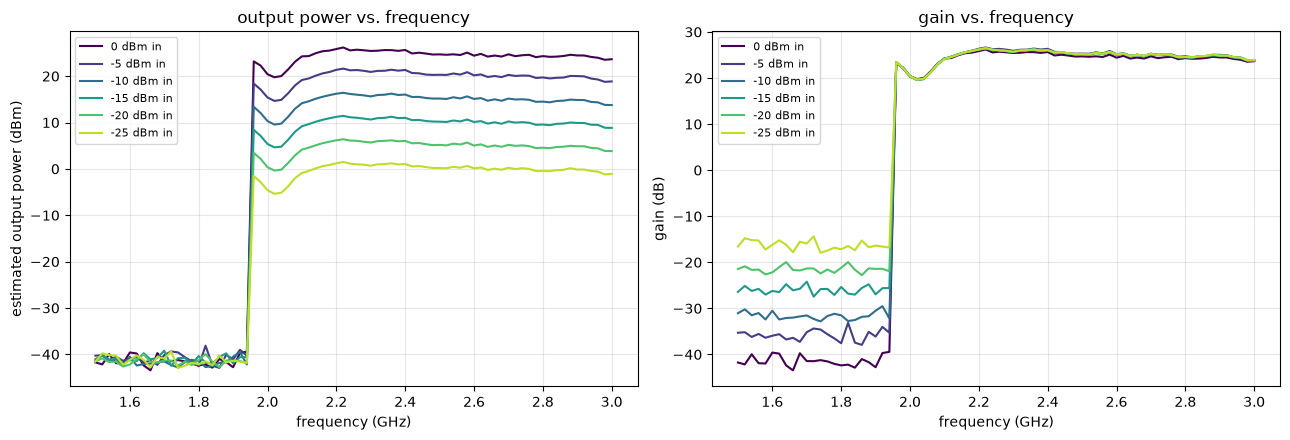

In [37]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(POWER_LIST_DBM)))

for power_dbm, color in zip(POWER_LIST_DBM, colors):
    d = results[power_dbm]
    axes[0].plot(d["freqs_hz"] / 1e9, d["estimated_output_dbm"], color=color,
                 label=f"{power_dbm:g} dBm in")
    axes[1].plot(d["freqs_hz"] / 1e9, d["gain_db"], color=color,
                 label=f"{power_dbm:g} dBm in")

axes[0].set_xlabel("frequency (GHz)")
axes[0].set_ylabel("estimated output power (dBm)")
axes[0].set_title("output power vs. frequency")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_xlabel("frequency (GHz)")
axes[1].set_ylabel("gain (dB)")
axes[1].set_title("gain vs. frequency")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

fig.tight_layout()

print(f"{'power (dBm)':>12} {'mean gain (dB)':>15} {'min gain (dB)':>15} {'max gain (dB)':>15} {'flatness (dB)':>15}")
for power_dbm in POWER_LIST_DBM:
    g = results[power_dbm]["gain_db"]
    print(f"{power_dbm:12g} {g.mean():15.2f} {g.min():15.2f} {g.max():15.2f} {np.ptp(g):15.2f}")

## Cleanup

In [38]:
gen.rf_off()
gen.go_to_local()
gen.close()
sa.go_to_local()
sa.close()
awg.write("OUTPUT2 OFF")
awg.close()

## Analysis from saved data

Reproduces the overlay plot straight from the saved per-power CSVs (`data/
new_amplifier_power_scan_<tag>.csv`) rather than the in-memory `results` dict
above -- no live instrument connection needed, can be re-run standalone.

 power (dBm)  mean gain (dB)   min gain (dB)   max gain (dB)   flatness (dB)
           0            4.44          -43.45           26.18           69.63
          -5            6.45          -37.91           26.62           64.54
         -10            7.64          -32.82           26.41           59.23
         -15            9.36          -27.45           26.43           53.88
         -20           10.70          -22.78           26.39           49.18
         -25           12.30          -17.95           26.50           44.44


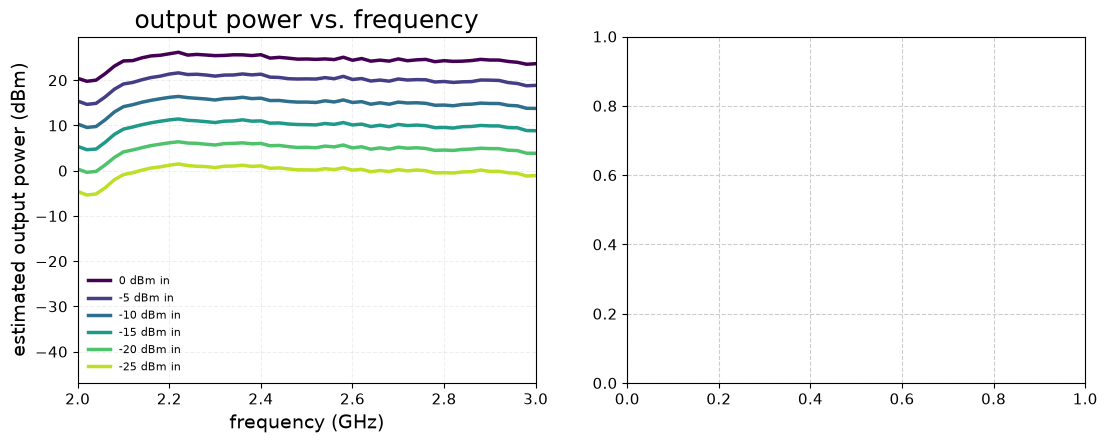

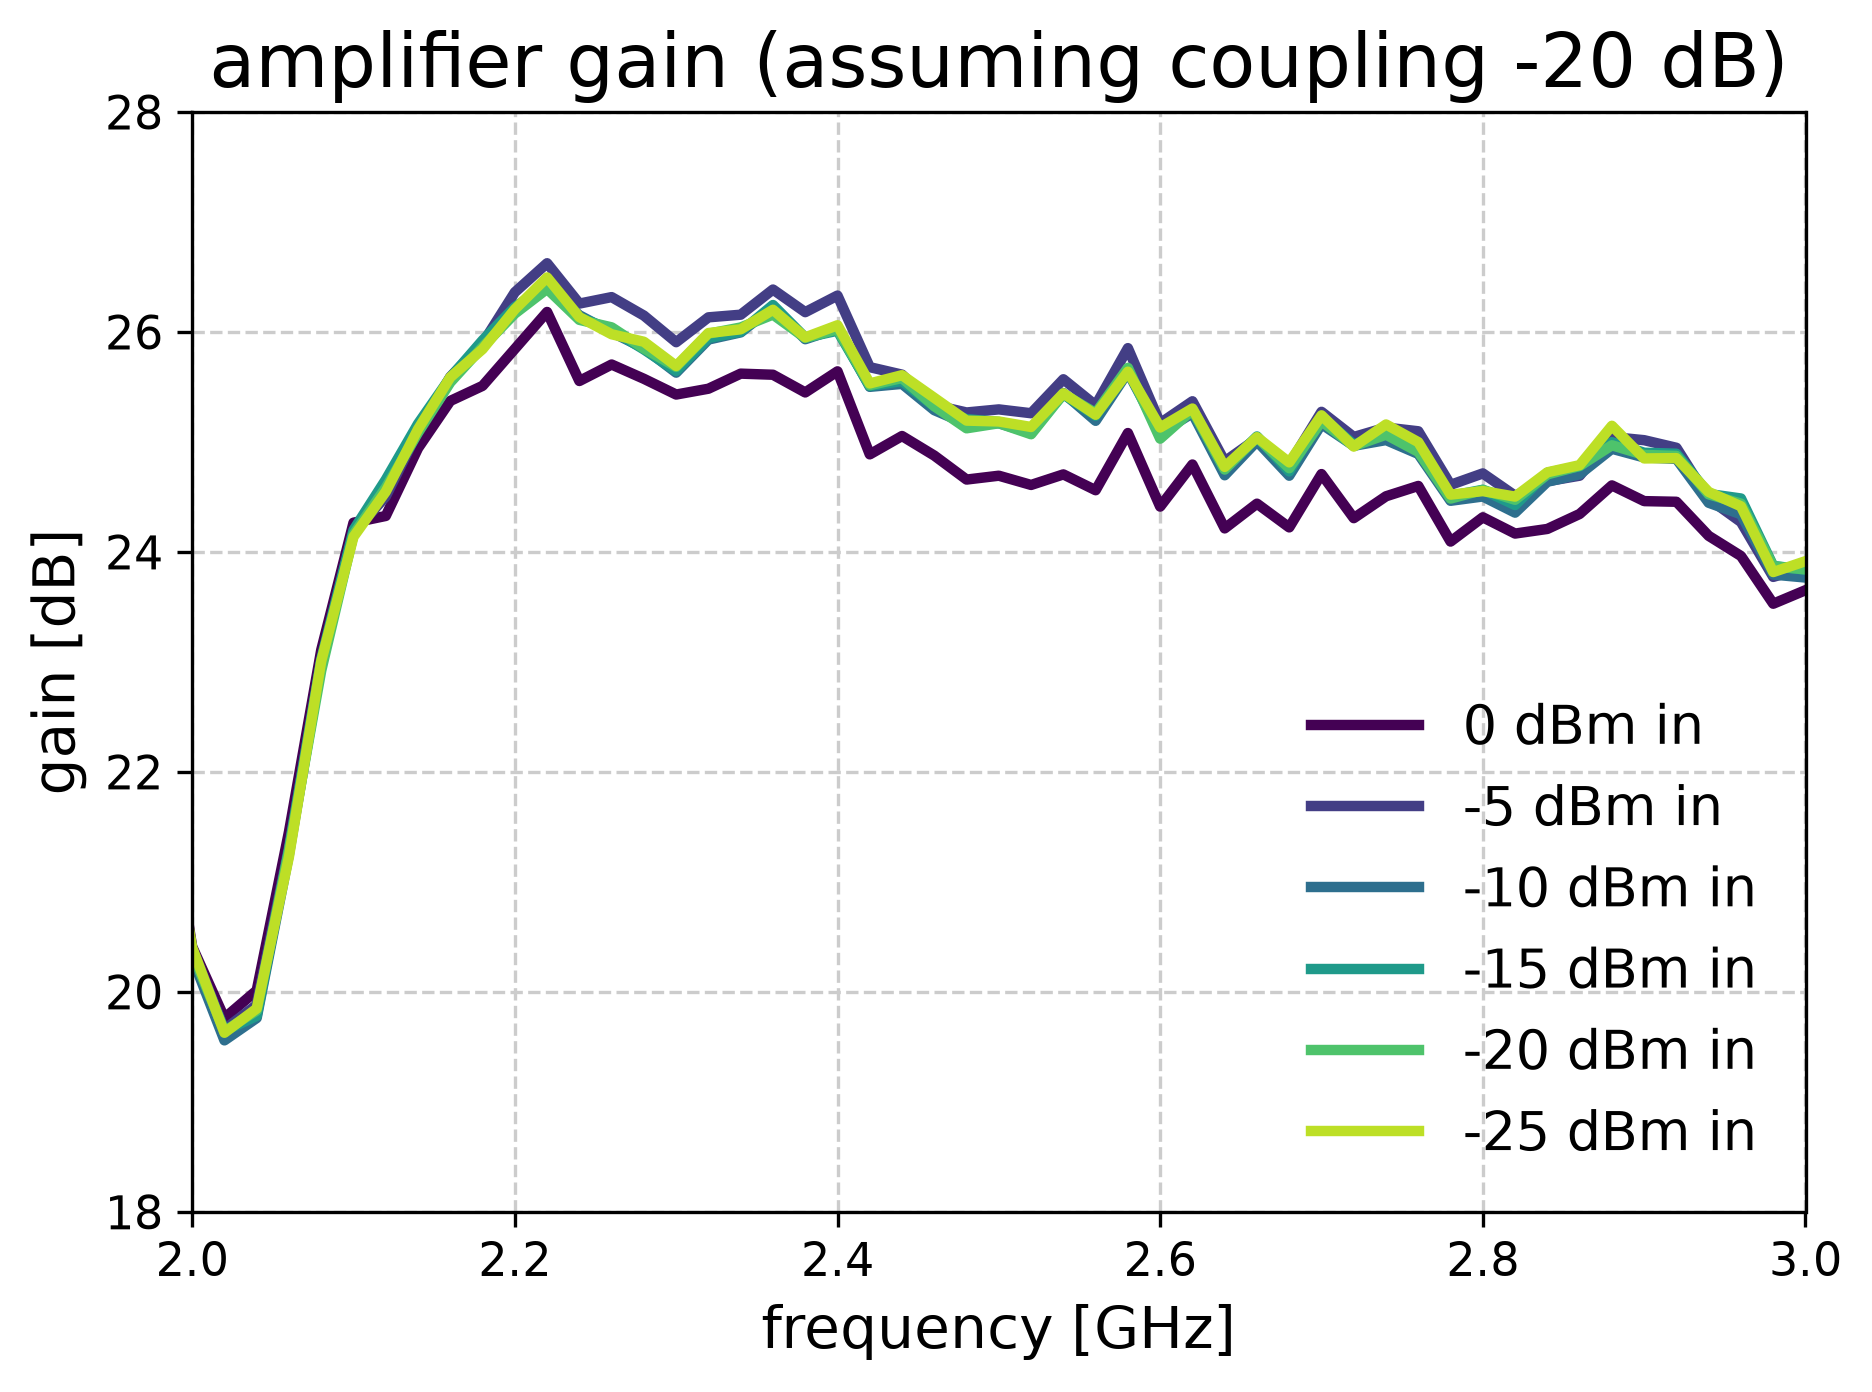

In [18]:

import os
import sys

import numpy as np
import matplotlib.pyplot as plt
plt.style.use("../plots.mplstyle")


with open("data/new_amplifier_power_scan_metadata.txt") as fh:
    saved_metadata = dict(
        line.split("=", 1) for line in fh.read().strip().splitlines()
    )
power_list_saved = [float(p) for p in saved_metadata["power_list_dbm"].split(",")]

results_saved = {}
for power_dbm in power_list_saved:
    tag = _power_tag(power_dbm)
    d = np.genfromtxt(f"data/new_amplifier_power_scan_{tag}.csv", delimiter=",", names=True)
    results_saved[power_dbm] = d

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig, ax = plt.subplots(dpi=300)
axes[1] = ax
colors = plt.cm.viridis(np.linspace(0, 0.9, len(power_list_saved)))

for power_dbm, color in zip(power_list_saved, colors):
    d = results_saved[power_dbm]
    axes[0].plot(d["frequency_hz"] / 1e9, d["estimated_output_dbm"], color=color,
                 label=f"{power_dbm:g} dBm in")
    axes[1].plot(d["frequency_hz"] / 1e9, d["gain_db"], color=color,
                 label=f"{power_dbm:g} dBm in")

axes[0].set_xlabel("frequency (GHz)")
axes[0].set_ylabel("estimated output power (dBm)")
axes[0].set_title("output power vs. frequency")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)
axes[0].set_xlim([2,3])



axes[1].set_xlabel("frequency [GHz]")
axes[1].set_ylabel("gain [dB]")
axes[1].set_title("amplifier gain (assuming coupling -20 dB)")
axes[1].set_xlim([2,3])
axes[1].set_ylim([18,28])
axes[1].legend()


fig.tight_layout()

print(f"{'power (dBm)':>12} {'mean gain (dB)':>15} {'min gain (dB)':>15} {'max gain (dB)':>15} {'flatness (dB)':>15}")
for power_dbm in power_list_saved:
    g = results_saved[power_dbm]["gain_db"]
    print(f"{power_dbm:12g} {g.mean():15.2f} {g.min():15.2f} {g.max():15.2f} {np.ptp(g):15.2f}")